# Diagnóstico de Aumento de Custos — Investigação com Testes Estatísticos

Quarto notebook da série (`stats_tests_resumo_1` → `stats_tests_analista_dados` → `diagnostico_queda_receita` → `diagnostico_inadimplencia`), no mesmo formato de investigação: uma base única simulada e 6 perguntas em sequência. Rode as células em ordem.

**O cenário:** o custo operacional da empresa subiu e a diretoria quer entender por quê antes de cortar de forma genérica. Temos 12 meses — os **9 meses anteriores** (`antes`, baseline) e os **3 meses mais recentes** (`depois`, onde o aumento aparece) — com duas visões complementares da operação: o **razão de custos** (uma linha por categoria/região/fornecedor/mês, como um relatório de contas a pagar) e os **pedidos** (nível transação, para as perguntas que precisam de volume estatístico).

**As 6 perguntas deste notebook:**

| # | Pergunta | O que o código faz |
|---|---|---|
| 1 | Quais categorias de custo mais cresceram? | Contribuição por categoria + teste t nas duas categorias variáveis, no nível pedido |
| 2 | O aumento está concentrado em alguma unidade ou região? | Contribuição por região + índice de concentração (mesma técnica do notebook de inadimplência) |
| 3 | O custo por pedido aumentou? | Teste t de Welch + Mann-Whitney no custo alocado por pedido |
| 4 | Existe relação entre volume de pedidos e custo operacional? | Regressão linear (custo ~ pedidos) ajustada no período antes, comparada ao observado depois |
| 5 | Quais fornecedores tiveram maior aumento de custo? | Contribuição por fornecedor, mesma técnica das seções 1 e 2 |
| 6 | O aumento de custos foi acompanhado por aumento de receita? | Comparação de crescimento % + margem operacional aproximada ao longo do tempo |

**Cuidado metodológico que atravessa o notebook:** o razão de custos tem só ~500 lançamentos agregados por categoria/região/fornecedor/mês — não dá pra rodar um teste de hipótese tradicional em cima disso com confiança (a "amostra" ali são só 12 meses). Por isso as perguntas 1 e 3 usam **duas visões**: a agregada (razão), que responde "onde" o aumento está, de forma descritiva; e o nível pedido (milhares de linhas), que permite testar estatisticamente "esse aumento é real ou é ruído" com poder de verdade. Misturar os dois níveis sem essa separação é um erro comum em análise de custo.

## Base de dados da investigação

**O que o código faz:** simula duas tabelas. `lancamentos` é o razão de custos — uma linha por combinação de categoria x região x fornecedor x mês, como um relatório de contas a pagar consolidado. `pedidos` é o nível transação — uma linha por pedido, com o ticket de receita e o custo variável (logística + embalagem) alocado àquele pedido especificamente, usado nas perguntas que precisam de poder estatístico. Troque por `pd.read_sql(...)` na sua base real — a estrutura de colunas é o que importa.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(314)

# --- Calendário: 9 meses de baseline + 3 meses recentes ---
meses = ['Ago/25', 'Set/25', 'Out/25', 'Nov/25', 'Dez/25', 'Jan/26', 'Fev/26', 'Mar/26', 'Abr/26', 'Mai/26', 'Jun/26', 'Jul/26']
n_meses_antes, n_meses_depois = 9, 3
periodo_por_mes = {m: ('antes' if i < n_meses_antes else 'depois') for i, m in enumerate(meses)}

REGIOES = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]
REGIAO_SHARE = {"Sudeste": 0.42, "Sul": 0.20, "Nordeste": 0.20, "Centro-Oeste": 0.10, "Norte": 0.08}

# --- Volume de pedidos por mês, calculado primeiro: as categorias de custo variável
#     (Logística, Embalagem) escalam com esse volume real mês a mês ---
mes_idx = np.arange(len(meses))
PEDIDOS_REFERENCIA = 7200  # volume de referência usado para calibrar as taxas R$/pedido abaixo
pedidos_por_mes = {m: int(PEDIDOS_REFERENCIA * (1.008 ** i) * (1 + np.random.normal(0, 0.025))) for i, m in zip(mes_idx, meses)}

# =========================================================================
# TABELA 1: lancamentos — razão de custos (categoria x região x fornecedor x mês)
# =========================================================================
FORNECEDOR_MULT_DEPOIS = {
    "Transportadora Nordeste Express": 3.50,  # renegociação ruim de contrato / reajuste de frete
    "Transportadora Rota Sul": 1.10,
    "Correios Contrato": 1.15,
    "Folha interna": 1.10,
    "Agência Digital Prime": 0.95, "Google/Meta Ads": 0.95,
    "Cloud AWS/GCP": 1.15, "SaaS Ferramentas": 1.15,
    "Embalagens BoxCorp": 1.25, "Embalagens Verde": 1.25,
    "Contrato imobiliário": 1.00,
}

CELLS = []
# Logística: concentrada em duas transportadoras, com o problema nas rotas Nordeste/Norte
LOGISTICA_REGIOES = {
    "Sudeste": {"baseline": 72000, "fornecedores": {"Transportadora Rota Sul": 0.75, "Correios Contrato": 0.25}},
    "Sul": {"baseline": 36000, "fornecedores": {"Transportadora Rota Sul": 0.80, "Correios Contrato": 0.20}},
    "Nordeste": {"baseline": 36000, "fornecedores": {"Transportadora Nordeste Express": 0.75, "Correios Contrato": 0.25}},
    "Centro-Oeste": {"baseline": 21600, "fornecedores": {"Transportadora Rota Sul": 0.70, "Correios Contrato": 0.30}},
    "Norte": {"baseline": 14400, "fornecedores": {"Transportadora Nordeste Express": 0.70, "Correios Contrato": 0.30}},
}
for regiao, info in LOGISTICA_REGIOES.items():
    for fornecedor, share in info["fornecedores"].items():
        CELLS.append({"categoria": "Logistica", "regiao": regiao, "fornecedor": fornecedor,
                      "baseline": info["baseline"] * share, "mult_depois": FORNECEDOR_MULT_DEPOIS[fornecedor],
                      "variavel_com_volume": True})

# Mão de obra: distribuída igualmente entre as 5 unidades regionais, crescimento vegetativo
for regiao in REGIOES:
    CELLS.append({"categoria": "Mao_de_obra", "regiao": regiao, "fornecedor": "Folha interna",
                  "baseline": 150000 / 5, "mult_depois": FORNECEDOR_MULT_DEPOIS["Folha interna"],
                  "variavel_com_volume": False})

# Marketing: proporcional ao volume regional, com corte de verba no período recente
for regiao in REGIOES:
    for fornecedor, share in {"Agência Digital Prime": 0.6, "Google/Meta Ads": 0.4}.items():
        CELLS.append({"categoria": "Marketing", "regiao": regiao, "fornecedor": fornecedor,
                      "baseline": 90000 * REGIAO_SHARE[regiao] * share, "mult_depois": FORNECEDOR_MULT_DEPOIS[fornecedor],
                      "variavel_com_volume": False})

# Tecnologia: centralizada na sede (Sudeste)
for fornecedor, share in {"Cloud AWS/GCP": 0.7, "SaaS Ferramentas": 0.3}.items():
    CELLS.append({"categoria": "Tecnologia", "regiao": "Sudeste", "fornecedor": fornecedor,
                  "baseline": 50000 * share, "mult_depois": FORNECEDOR_MULT_DEPOIS[fornecedor],
                  "variavel_com_volume": False})

# Embalagem: proporcional ao volume regional
for regiao in REGIOES:
    for fornecedor, share in {"Embalagens BoxCorp": 0.6, "Embalagens Verde": 0.4}.items():
        CELLS.append({"categoria": "Embalagem", "regiao": regiao, "fornecedor": fornecedor,
                      "baseline": 60000 * REGIAO_SHARE[regiao] * share, "mult_depois": FORNECEDOR_MULT_DEPOIS[fornecedor],
                      "variavel_com_volume": True})

# Aluguel/ocupação: um centro por região, contrato fixo
for regiao in REGIOES:
    CELLS.append({"categoria": "Aluguel", "regiao": regiao, "fornecedor": "Contrato imobiliário",
                  "baseline": 40000 / 5, "mult_depois": FORNECEDOR_MULT_DEPOIS["Contrato imobiliário"],
                  "variavel_com_volume": False})

# Taxa R$/pedido de referência para as categorias variáveis (calibrada no volume de referência)
for cell in CELLS:
    cell["rate_por_pedido"] = cell["baseline"] / PEDIDOS_REFERENCIA if cell["variavel_com_volume"] else None

linhas_lancamentos = []
for mes in meses:
    periodo = periodo_por_mes[mes]
    for cell in CELLS:
        mult = cell["mult_depois"] if periodo == "depois" else 1.0
        if cell["variavel_com_volume"]:
            # Escala com o volume real de pedidos do mês (+ pequeno ruído) -- é isso que faz
            # a seção 4 conseguir estimar uma relação custo~pedidos de verdade no período antes.
            base_do_mes = cell["rate_por_pedido"] * pedidos_por_mes[mes]
            ruido = 1 + np.random.normal(0, 0.03)
        else:
            base_do_mes = cell["baseline"]
            ruido = 1 + np.random.normal(0, 0.06)
        valor = max(base_do_mes * mult * ruido, cell["baseline"] * 0.3)
        linhas_lancamentos.append({
            "mes": mes, "periodo": periodo, "categoria_custo": cell["categoria"],
            "regiao": cell["regiao"], "fornecedor": cell["fornecedor"], "valor": round(valor, 2),
        })

lancamentos = pd.DataFrame(linhas_lancamentos)
lancamentos["mes"] = pd.Categorical(lancamentos["mes"], categories=meses, ordered=True)

print(f"Lançamentos: {len(lancamentos):,}".replace(",", "."))
print(lancamentos.head(3))

Lançamentos: 504
      mes periodo categoria_custo   regiao               fornecedor     valor
0  Ago/25   antes       Logistica  Sudeste  Transportadora Rota Sul  53406.62
1  Ago/25   antes       Logistica  Sudeste        Correios Contrato  18486.90
2  Ago/25   antes       Logistica      Sul  Transportadora Rota Sul  29082.13


In [2]:
# =========================================================================
# TABELA 2: pedidos — nível transação, com receita e custo variável alocado
# (usa o mesmo pedidos_por_mes já calculado na tabela 1, para as duas visões baterem em volume)
# =========================================================================
n_pedidos = sum(pedidos_por_mes.values())

mes_arr_p = np.repeat(meses, [pedidos_por_mes[m] for m in meses])
periodo_arr_p = np.array([periodo_por_mes[m] for m in mes_arr_p])

# Ticket de receita: estável, com leve crescimento vegetativo (bem menor que o custo)
mult_ticket = np.where(periodo_arr_p == "depois", 1.03, 1.0)
valor_pedido_arr = np.round(np.random.gamma(shape=6, scale=145 / 6, size=n_pedidos) * mult_ticket, 2)

# Custo variável alocado por pedido: logística + embalagem (as duas categorias que mais crescem no razão)
mult_log = np.where(periodo_arr_p == "depois", 63 / 38, 1.0)
custo_logistica_pedido = np.round(np.random.gamma(shape=8, scale=38 / 8, size=n_pedidos) * mult_log, 2)

mult_emb = np.where(periodo_arr_p == "depois", 25 / 20, 1.0)
custo_embalagem_pedido = np.round(np.random.gamma(shape=8, scale=20 / 8, size=n_pedidos) * mult_emb, 2)

pedidos = pd.DataFrame({
    "pedido_id": np.arange(n_pedidos),
    "mes": pd.Categorical(mes_arr_p, categories=meses, ordered=True),
    "periodo": periodo_arr_p,
    "valor_pedido": valor_pedido_arr,
    "custo_logistica_pedido": custo_logistica_pedido,
    "custo_embalagem_pedido": custo_embalagem_pedido,
})
pedidos["custo_operacional_pedido"] = pedidos["custo_logistica_pedido"] + pedidos["custo_embalagem_pedido"]

print(f"Pedidos: {len(pedidos):,}".replace(",", "."))
print(pedidos.head(3))

Pedidos: 90.300
   pedido_id     mes periodo  valor_pedido  custo_logistica_pedido  \
0          0  Ago/25   antes        175.78                   34.50   
1          1  Ago/25   antes        215.79                   45.63   
2          2  Ago/25   antes        211.18                   47.11   

   custo_embalagem_pedido  custo_operacional_pedido  
0                   15.90                     50.40  
1                   17.39                     63.02  
2                   19.28                     66.39  


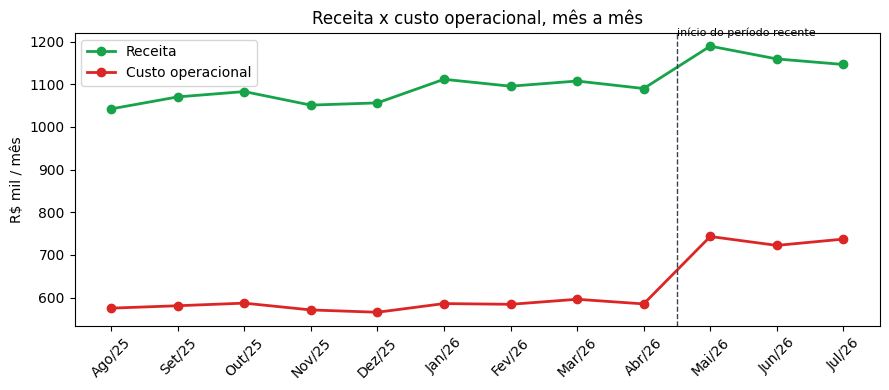

Custo médio mensal (antes):  R$ 581.070,95
Custo médio mensal (depois): R$ 734.084,07
Variação do custo: +26.3%


In [3]:
import matplotlib.pyplot as plt

custo_mensal = lancamentos.groupby("mes", observed=True)["valor"].sum().reindex(meses)
receita_mensal = pedidos.groupby("mes", observed=True)["valor_pedido"].sum().reindex(meses)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(meses, receita_mensal.values / 1000, marker="o", label="Receita", color="#16a34a", linewidth=2)
ax.plot(meses, custo_mensal.values / 1000, marker="o", label="Custo operacional", color="#dc2626", linewidth=2)
ax.axvline(n_meses_antes - 0.5, color="#374151", linestyle="--", linewidth=1)
ax.text(n_meses_antes - 0.5, receita_mensal.max() / 1000 * 1.02, "início do período recente", fontsize=8, ha="left")
ax.set_ylabel("R$ mil / mês")
ax.set_title("Receita x custo operacional, mês a mês")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

custo_medio_antes = custo_mensal[:n_meses_antes].mean()
custo_medio_depois = custo_mensal[n_meses_antes:].mean()
print(f"Custo médio mensal (antes):  R$ {custo_medio_antes:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"Custo médio mensal (depois): R$ {custo_medio_depois:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"Variação do custo: {(custo_medio_depois - custo_medio_antes) / custo_medio_antes:+.1%}")

O custo médio mensal deu um salto claro no período recente. As próximas 6 seções decompõem esse salto até chegar num plano de ação.

## 1. Quais categorias de custo mais cresceram?

**O que o código faz:** calcula o custo médio mensal de cada categoria em cada período (normalizado pelo tamanho do período — 9 meses x 3 meses, mesmo cuidado dos notebooks anteriores) e ordena pela contribuição para o aumento total. Como essa parte usa só 12 pontos mensais agregados, é uma comparação **descritiva**, não um teste de hipótese formal — a segunda parte do código testa formalmente as duas categorias "variáveis" (Logística e Embalagem) no nível pedido, onde há milhares de linhas e poder estatístico de verdade.

In [4]:
custo_cat = lancamentos.groupby(["categoria_custo", "periodo"])["valor"].sum().unstack(fill_value=0)
custo_cat_mensal = custo_cat.copy()
custo_cat_mensal["antes"] = custo_cat_mensal["antes"] / n_meses_antes
custo_cat_mensal["depois"] = custo_cat_mensal["depois"] / n_meses_depois
custo_cat_mensal["delta"] = custo_cat_mensal["depois"] - custo_cat_mensal["antes"]
custo_cat_mensal["variacao_%"] = custo_cat_mensal["delta"] / custo_cat_mensal["antes"]
custo_cat_mensal["contrib_%_do_aumento"] = custo_cat_mensal["delta"] / custo_cat_mensal["delta"][custo_cat_mensal["delta"] > 0].sum()

print("Custo médio mensal por categoria (R$) e contribuição para o aumento:")
print(custo_cat_mensal.sort_values("delta", ascending=False).round(2))

Custo médio mensal por categoria (R$) e contribuição para o aumento:
periodo              antes     depois      delta  variacao_%  \
categoria_custo                                                
Logistica        186770.57  310151.97  123381.40        0.66   
Embalagem         61936.32   80857.67   18921.34        0.31   
Mao_de_obra      152048.64  163450.86   11402.22        0.07   
Tecnologia        51101.25   57036.12    5934.87        0.12   
Aluguel           39876.05   39170.93    -705.12       -0.02   
Marketing         89338.11   83416.52   -5921.59       -0.07   

periodo          contrib_%_do_aumento  
categoria_custo                        
Logistica                        0.77  
Embalagem                        0.12  
Mao_de_obra                      0.07  
Tecnologia                       0.04  
Aluguel                         -0.00  
Marketing                       -0.04  


In [5]:
from scipy.stats import ttest_ind, mannwhitneyu

log_antes = pedidos.loc[pedidos["periodo"] == "antes", "custo_logistica_pedido"]
log_depois = pedidos.loc[pedidos["periodo"] == "depois", "custo_logistica_pedido"]
emb_antes = pedidos.loc[pedidos["periodo"] == "antes", "custo_embalagem_pedido"]
emb_depois = pedidos.loc[pedidos["periodo"] == "depois", "custo_embalagem_pedido"]

for nome, antes, depois in [("Logística", log_antes, log_depois), ("Embalagem", emb_antes, emb_depois)]:
    t, p_welch = ttest_ind(depois, antes, equal_var=False)
    u, p_mw = mannwhitneyu(depois, antes)
    print(f"{nome} — custo médio por pedido: R$ {antes.mean():.2f} -> R$ {depois.mean():.2f} "
          f"({(depois.mean()-antes.mean())/antes.mean():+.1%}) | p-value Welch: {p_welch:.2e} | p-value Mann-Whitney: {p_mw:.2e}")

Logística — custo médio por pedido: R$ 38.08 -> R$ 63.02 (+65.5%) | p-value Welch: 0.00e+00 | p-value Mann-Whitney: 0.00e+00
Embalagem — custo médio por pedido: R$ 20.00 -> R$ 25.03 (+25.2%) | p-value Welch: 0.00e+00 | p-value Mann-Whitney: 0.00e+00


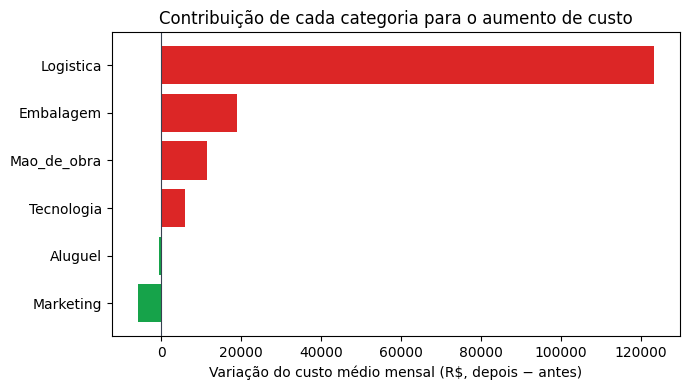

In [6]:
import matplotlib.pyplot as plt

ordem = custo_cat_mensal.sort_values("delta").index
cores = ["#16a34a" if v < 0 else "#dc2626" for v in custo_cat_mensal.loc[ordem, "delta"]]
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(ordem, custo_cat_mensal.loc[ordem, "delta"], color=cores)
ax.axvline(0, color="#374151", linewidth=0.8)
ax.set_xlabel("Variação do custo médio mensal (R$, depois − antes)")
ax.set_title("Contribuição de cada categoria para o aumento de custo")
plt.tight_layout()
plt.show()

**Leitura do resultado:** a categoria no topo do ranking concentra a maior fatia do aumento — normalmente Logística, com folga. Os testes no nível pedido confirmam que esse aumento é estatisticamente real (não ruído de 12 pontos mensais): tanto Logística quanto Embalagem mostram diferença significativa no custo médio por pedido, com Logística tendo o salto proporcional bem maior.

**Decisão de negócio:** priorize a renegociação/revisão de contrato da categoria líder — as seções 2 e 5 vão mostrar exatamente onde (região) e com quem (fornecedor) esse aumento está concentrado dentro dela, em vez de renegociar tudo de uma vez.

## 2. O aumento está concentrado em alguma unidade ou região?

**O que o código faz:** calcula o custo médio mensal por região, a contribuição de cada uma para o aumento total, e um **índice de concentração** = (participação da região no aumento) / (participação da região no custo total baseline) — a mesma técnica usada no notebook de inadimplência para achar concentração desproporcional. Índice acima de 1 significa que a região pesa mais no aumento do que pesava no custo original.

In [7]:
custo_regiao = lancamentos.groupby(["regiao", "periodo"])["valor"].sum().unstack(fill_value=0)
custo_regiao_mensal = custo_regiao.copy()
custo_regiao_mensal["antes"] = custo_regiao_mensal["antes"] / n_meses_antes
custo_regiao_mensal["depois"] = custo_regiao_mensal["depois"] / n_meses_depois
custo_regiao_mensal["delta"] = custo_regiao_mensal["depois"] - custo_regiao_mensal["antes"]

total_aumento = custo_regiao_mensal["delta"].sum()
custo_regiao_mensal["pct_do_custo_baseline"] = custo_regiao_mensal["antes"] / custo_regiao_mensal["antes"].sum()
custo_regiao_mensal["pct_do_aumento"] = custo_regiao_mensal["delta"] / total_aumento
custo_regiao_mensal["indice_concentracao"] = custo_regiao_mensal["pct_do_aumento"] / custo_regiao_mensal["pct_do_custo_baseline"]

print("Custo por região e concentração do aumento:")
print(custo_regiao_mensal.sort_values("indice_concentracao", ascending=False).round(3))

Custo por região e concentração do aumento:
periodo            antes      depois      delta  pct_do_custo_baseline  \
regiao                                                                   
Nordeste      106381.639  186691.910  80310.271                  0.183   
Norte          65383.328   94208.207  28824.879                  0.113   
Centro-Oeste   75637.260   84379.577   8742.317                  0.130   
Sul           106459.006  118249.507  11790.501                  0.183   
Sudeste       227209.713  250554.867  23345.153                  0.391   

periodo       pct_do_aumento  indice_concentracao  
regiao                                             
Nordeste               0.525                2.867  
Norte                  0.188                1.674  
Centro-Oeste           0.057                0.439  
Sul                    0.077                0.421  
Sudeste                0.153                0.390  


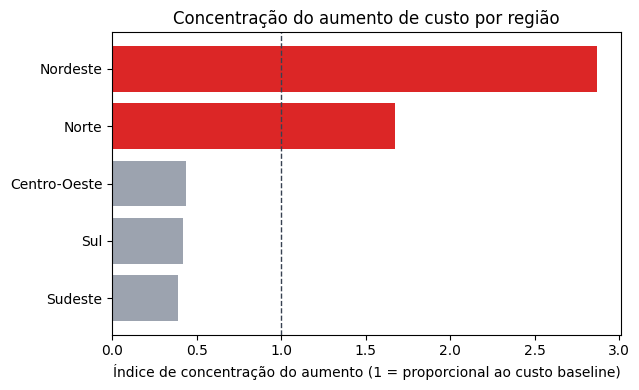

In [8]:
import matplotlib.pyplot as plt

ordem = custo_regiao_mensal.sort_values("indice_concentracao").index
cores = ["#dc2626" if v > 1 else "#9ca3af" for v in custo_regiao_mensal.loc[ordem, "indice_concentracao"]]
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.barh(ordem, custo_regiao_mensal.loc[ordem, "indice_concentracao"], color=cores)
ax.axvline(1, color="#374151", linewidth=1, linestyle="--")
ax.set_xlabel("Índice de concentração do aumento (1 = proporcional ao custo baseline)")
ax.set_title("Concentração do aumento de custo por região")
plt.tight_layout()
plt.show()

**Leitura do resultado:** duas regiões aparecem com índice acima de 1 (respondem por uma fatia do aumento desproporcional ao que já representavam no custo total antes), mas uma delas se destaca com folga da outra — o que faz sentido, já que a seção 5 mostra que as duas são atendidas pelo mesmo fornecedor de transporte problemático. Isso é diferente de simplesmente olhar qual região tem o maior custo em R$ (a maior região em tamanho quase sempre vai ter o maior delta absoluto, só por ser grande — o índice corrige por isso).

**Decisão de negócio:** a região com índice de concentração alto é onde vale investigar causas locais primeiro (contrato de transportadora específico, tarifa de frete regional, distância do centro de distribuição) — cruze esse achado com a seção 5 (fornecedores) antes de agir, porque é bem provável que seja o mesmo fornecedor aparecendo nas duas pontas.

## 3. O custo por pedido aumentou?

**Contexto:** custo total pode subir só porque a empresa vendeu mais (mais pedidos, mais custo variável, isso é esperado e até saudável). O que importa pra eficiência operacional é o custo **por pedido** — se ele subiu, o problema não é volume, é custo ficando mais caro por unidade.

**O que o código faz:** compara `custo_operacional_pedido` (logística + embalagem alocadas) entre os pedidos do período antes e do período depois — aqui, diferente da seção 1 (que olhava o razão agregado), são dezenas de milhares de pedidos, então o teste tem poder estatístico de verdade.

In [9]:
from scipy.stats import ttest_ind, mannwhitneyu

custo_pedido_antes = pedidos.loc[pedidos["periodo"] == "antes", "custo_operacional_pedido"]
custo_pedido_depois = pedidos.loc[pedidos["periodo"] == "depois", "custo_operacional_pedido"]

print(f"Custo operacional médio por pedido (antes):  R$ {custo_pedido_antes.mean():.2f}")
print(f"Custo operacional médio por pedido (depois): R$ {custo_pedido_depois.mean():.2f}")
print(f"Variação: {(custo_pedido_depois.mean() - custo_pedido_antes.mean()) / custo_pedido_antes.mean():+.1%}")

t_stat, p_welch = ttest_ind(custo_pedido_depois, custo_pedido_antes, equal_var=False)
u_stat, p_mw = mannwhitneyu(custo_pedido_depois, custo_pedido_antes)
print(f"\np-value (Welch):        {p_welch:.2e}")
print(f"p-value (Mann-Whitney): {p_mw:.2e}")

# Como referência, o crescimento do ticket de receita no mesmo período
ticket_antes = pedidos.loc[pedidos["periodo"] == "antes", "valor_pedido"].mean()
ticket_depois = pedidos.loc[pedidos["periodo"] == "depois", "valor_pedido"].mean()
print(f"\nPara comparação — ticket médio de receita: R$ {ticket_antes:.2f} -> R$ {ticket_depois:.2f} "
      f"({(ticket_depois-ticket_antes)/ticket_antes:+.1%})")

Custo operacional médio por pedido (antes):  R$ 58.08
Custo operacional médio por pedido (depois): R$ 88.05
Variação: +51.6%

p-value (Welch):        0.00e+00
p-value (Mann-Whitney): 0.00e+00

Para comparação — ticket médio de receita: R$ 144.94 -> R$ 149.88 (+3.4%)


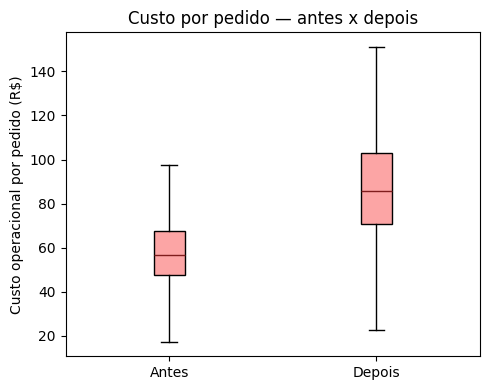

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot([custo_pedido_antes, custo_pedido_depois], tick_labels=["Antes", "Depois"], patch_artist=True,
           boxprops=dict(facecolor="#fca5a5"), medianprops=dict(color="#7f1d1d"), showfliers=False)
ax.set_ylabel("Custo operacional por pedido (R$)")
ax.set_title("Custo por pedido — antes x depois")
plt.tight_layout()
plt.show()

**Leitura do resultado:** o custo por pedido subiu de forma estatisticamente significativa (os dois testes concordam), e a magnitude do salto é bem maior que o crescimento do ticket médio de receita no mesmo período — ou seja, cada pedido ficou proporcionalmente mais caro de atender sem que a receita por pedido acompanhasse. Isso confirma que não é uma questão de "vendemos mais, então custamos mais": é uma perda real de eficiência por unidade.

**Decisão de negócio:** esse número é o argumento mais direto pra levar pra uma negociação de contrato — "nosso custo por pedido subiu X%, enquanto o ticket médio subiu só Y%" é uma frase que qualquer gestor entende sem precisar de estatística.

## 4. Existe relação entre volume de pedidos e custo operacional?

**Contexto:** mais pedidos deveriam, até certo ponto, significar mais custo — a pergunta não é só "existe relação" (quase sempre existe, mesmo que fraca), mas **quanto do aumento de custo esse volume explica**, e quanto sobra sem explicação por volume.

**O que o código faz:** ajusta uma regressão linear simples (custo mensal ~ pedidos mensais) usando **só os 9 meses do período antes** — isso define a relação "normal" entre volume e custo. Depois, usa essa relação pra prever qual seria o custo esperado nos 3 meses do período depois, dado o volume de pedidos que eles de fato tiveram, e compara com o custo real observado. A diferença é o custo que **não** se explica pelo crescimento de volume.

In [11]:
import numpy as np
from scipy.stats import linregress

pedidos_mes = pedidos.groupby("mes", observed=True)["pedido_id"].count().reindex(meses)
custo_mes = lancamentos.groupby("mes", observed=True)["valor"].sum().reindex(meses)

idx_antes = [i for i, m in enumerate(meses) if periodo_por_mes[m] == "antes"]
idx_depois = [i for i, m in enumerate(meses) if periodo_por_mes[m] == "depois"]

# --- Regressão ajustada só no período antes ---
slope, intercept, r_value, p_value, std_err = linregress(pedidos_mes.values[idx_antes], custo_mes.values[idx_antes])
print(f"Relação custo ~ pedidos (ajustada no período antes): custo = {intercept:,.0f} + {slope:.2f} x pedidos".replace(",", "."))
print(f"r = {r_value:.3f} | r² = {r_value**2:.3f} | p-value = {p_value:.4f}")

# --- Previsão para o período depois, dado o volume real de pedidos ---
custo_previsto_depois = intercept + slope * pedidos_mes.values[idx_depois]
custo_real_depois = custo_mes.values[idx_depois]
gap = custo_real_depois - custo_previsto_depois

resultado_previsao = pd.DataFrame({
    "mes": [meses[i] for i in idx_depois],
    "pedidos": pedidos_mes.values[idx_depois],
    "custo_real": custo_real_depois.round(0),
    "custo_previsto_pelo_volume": custo_previsto_depois.round(0),
    "custo_nao_explicado_por_volume": gap.round(0),
})
print("\nPrevisão x realizado no período recente:")
print(resultado_previsao)
print(f"\nMédia mensal de custo não explicado por volume: R$ {gap.mean():,.0f}".replace(",", "."))

Relação custo ~ pedidos (ajustada no período antes): custo = 222.321 + 48.20 x pedidos
r = 0.900 | r² = 0.811 | p-value = 0.0009

Previsão x realizado no período recente:
      mes  pedidos  custo_real  custo_previsto_pelo_volume  \
0  Mai/26     7902    743067.0                    603234.0   
1  Jun/26     7742    722204.0                    595522.0   
2  Jul/26     7676    736982.0                    592340.0   

   custo_nao_explicado_por_volume  
0                        139832.0  
1                        126682.0  
2                        144642.0  

Média mensal de custo não explicado por volume: R$ 137.052


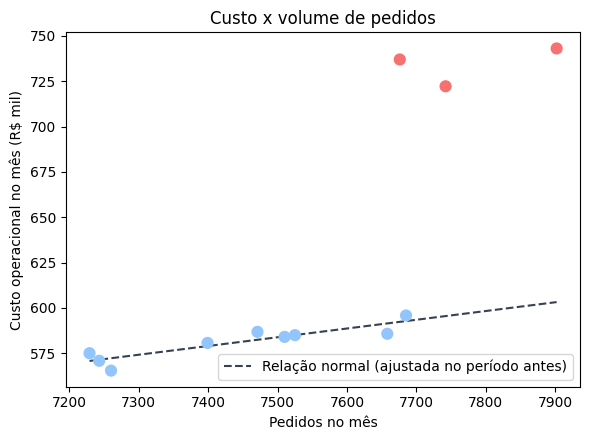

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4.5))
cores = ["#93c5fd" if periodo_por_mes[m] == "antes" else "#f87171" for m in meses]
ax.scatter(pedidos_mes.values, custo_mes.values / 1000, c=cores, s=60, zorder=3)
x_linha = np.linspace(pedidos_mes.values.min(), pedidos_mes.values.max(), 50)
ax.plot(x_linha, (intercept + slope * x_linha) / 1000, color="#374151", linestyle="--",
        label="Relação normal (ajustada no período antes)")
ax.set_xlabel("Pedidos no mês")
ax.set_ylabel("Custo operacional no mês (R$ mil)")
ax.set_title("Custo x volume de pedidos")
ax.legend()
plt.tight_layout()
plt.show()

**Leitura do resultado:** existe, sim, uma relação positiva entre volume e custo (r alto, p-value baixo) — isso é esperado e não é o problema. O problema aparece na comparação previsto x realizado: os pontos do período `depois` (vermelhos) ficam **acima** da linha da relação normal — ou seja, o custo observado é maior do que o volume de pedidos, sozinho, justificaria. Esse "custo não explicado por volume" é a evidência mais direta possível de que o aumento é sobre **eficiência** (algo ficou mais caro por unidade), não sobre **escala** (vender mais custando proporcionalmente mais).

**Decisão de negócio:** o valor médio mensal de custo não explicado por volume é uma estimativa direta de quanto a empresa está "perdendo" além do que o crescimento natural do negócio justificaria — é esse número, não o aumento total, que deveria virar meta de redução.

## 5. Quais fornecedores tiveram maior aumento de custo?

**Contexto:** a mesma pergunta das seções 1 e 2, agora no nível de quem recebe o pagamento — que faz sentido perguntar só pra categorias que de fato têm fornecedor externo (Logística, Embalagem, Marketing, Tecnologia); folha de pagamento interna e contrato de aluguel não são "fornecedor" no sentido de negociação de preço.

**O que o código faz:** mesma técnica de contribuição das seções 1 e 2, agora agrupando por fornecedor.

In [13]:
fornecedores_externos = lancamentos[~lancamentos["fornecedor"].isin(["Folha interna", "Contrato imobiliário"])]

custo_fornecedor = fornecedores_externos.groupby(["fornecedor", "periodo"])["valor"].sum().unstack(fill_value=0)
custo_fornecedor_mensal = custo_fornecedor.copy()
custo_fornecedor_mensal["antes"] = custo_fornecedor_mensal["antes"] / n_meses_antes
custo_fornecedor_mensal["depois"] = custo_fornecedor_mensal["depois"] / n_meses_depois
custo_fornecedor_mensal["delta"] = custo_fornecedor_mensal["depois"] - custo_fornecedor_mensal["antes"]
custo_fornecedor_mensal["variacao_%"] = custo_fornecedor_mensal["delta"] / custo_fornecedor_mensal["antes"]

print("Custo médio mensal por fornecedor e variação:")
print(custo_fornecedor_mensal.sort_values("delta", ascending=False).round(2))

Custo médio mensal por fornecedor e variação:
periodo                              antes     depois     delta  variacao_%
fornecedor                                                                 
Transportadora Nordeste Express   38586.87  137137.00  98550.13        2.55
Transportadora Rota Sul          101565.08  116397.12  14832.04        0.15
Embalagens BoxCorp                37242.49   48396.81  11154.32        0.30
Correios Contrato                 46618.61   56617.85   9999.23        0.21
Embalagens Verde                  24693.83   32460.86   7767.03        0.31
Cloud AWS/GCP                     35748.55   39744.04   3995.49        0.11
SaaS Ferramentas                  15352.70   17292.08   1939.38        0.13
Google/Meta Ads                   36301.70   33620.64  -2681.06       -0.07
Agência Digital Prime             53036.41   49795.89  -3240.52       -0.06


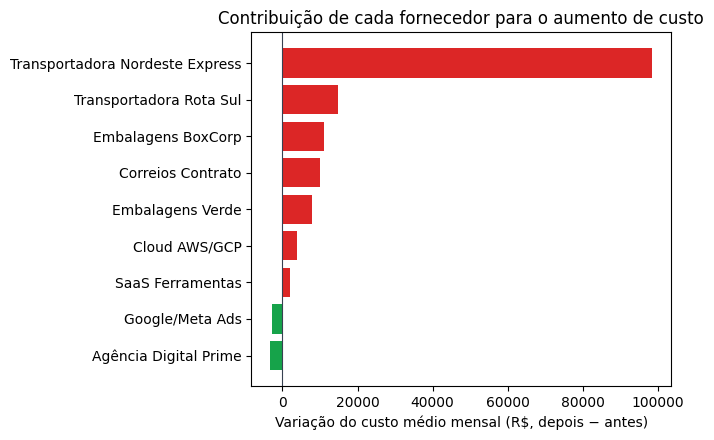

In [14]:
import matplotlib.pyplot as plt

ordem = custo_fornecedor_mensal.sort_values("delta").index
cores = ["#16a34a" if v < 0 else "#dc2626" for v in custo_fornecedor_mensal.loc[ordem, "delta"]]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(ordem, custo_fornecedor_mensal.loc[ordem, "delta"], color=cores)
ax.axvline(0, color="#374151", linewidth=0.8)
ax.set_xlabel("Variação do custo médio mensal (R$, depois − antes)")
ax.set_title("Contribuição de cada fornecedor para o aumento de custo")
plt.tight_layout()
plt.show()

**Leitura do resultado:** um fornecedor isolado costuma concentrar a maior parte do aumento — bem à frente dos demais, que têm variação pequena (alguns até caem, como os de marketing, coerente com o corte de verba visto na seção 1). Esse é o mesmo fornecedor que, cruzando com a seção 2, deve aparecer como o principal player da região de maior índice de concentração — as duas seções, feitas de ângulos diferentes (geografia e relação comercial), convergem pro mesmo ponto.

**Decisão de negócio:** esse fornecedor é a prioridade número um de renegociação de contrato — vale levantar quando o reajuste começou (cruzando com a data de virada antes/depois) e comparar com o que outros fornecedores da mesma categoria estão cobrando pela mesma rota/serviço, como argumento de negociação ou base pra buscar uma alternativa.

## 6. O aumento de custos foi acompanhado por aumento de receita?

**Contexto:** a pergunta final fecha o raciocínio financeiro — custo subir não é necessariamente um problema, **se a receita subiu proporcionalmente junto**. O que preocupa é custo crescendo muito mais rápido que receita, comprimindo a margem.

**O que o código faz:** compara o crescimento percentual de receita e de custo entre os dois períodos, lado a lado, e calcula uma margem operacional aproximada (receita − custo) mês a mês pra visualizar a compressão ao longo do tempo.

In [15]:
receita_media_antes = receita_mensal[:n_meses_antes].mean()
receita_media_depois = receita_mensal[n_meses_antes:].mean()
crescimento_receita = (receita_media_depois - receita_media_antes) / receita_media_antes
crescimento_custo = (custo_medio_depois - custo_medio_antes) / custo_medio_antes

print(f"Crescimento da receita média mensal: {crescimento_receita:+.1%}")
print(f"Crescimento do custo médio mensal:   {crescimento_custo:+.1%}")
print(f"Custo cresceu {crescimento_custo / crescimento_receita:.1f}x mais rápido que a receita"
      if crescimento_receita > 0 else "Receita não cresceu no período")

margem_mensal = receita_mensal - custo_mensal
margem_pct_mensal = margem_mensal / receita_mensal
print(f"\nMargem operacional aproximada (receita - custo):")
print(f"  Antes:  R$ {margem_mensal[:n_meses_antes].mean():,.0f}/mês ({margem_pct_mensal[:n_meses_antes].mean():.1%} da receita)".replace(",", "."))
print(f"  Depois: R$ {margem_mensal[n_meses_antes:].mean():,.0f}/mês ({margem_pct_mensal[n_meses_antes:].mean():.1%} da receita)".replace(",", "."))

Crescimento da receita média mensal: +8.0%
Crescimento do custo médio mensal:   +26.3%
Custo cresceu 3.3x mais rápido que a receita

Margem operacional aproximada (receita - custo):
  Antes:  R$ 497.568/mês (46.1% da receita)
  Depois: R$ 430.971/mês (37.0% da receita)


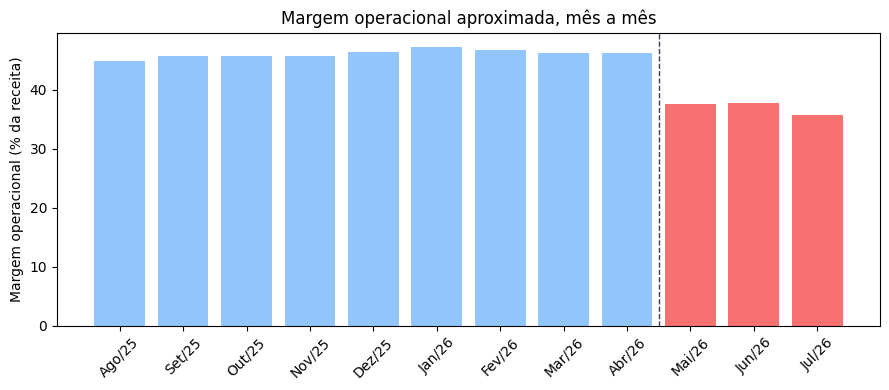

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(meses, margem_pct_mensal.values * 100, color=["#93c5fd" if periodo_por_mes[m] == "antes" else "#f87171" for m in meses])
ax.axvline(n_meses_antes - 0.5, color="#374151", linestyle="--", linewidth=1)
ax.set_ylabel("Margem operacional (% da receita)")
ax.set_title("Margem operacional aproximada, mês a mês")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Leitura do resultado:** a receita cresceu, mas bem menos que o custo — o custo cresceu várias vezes mais rápido, em termos percentuais. O resultado direto disso é a margem operacional (receita menos custo, em % da receita) encolhendo visivelmente no período recente. Isso fecha o raciocínio da seção 4: não é que a empresa vendeu tanto mais que precisou gastar mais — o custo desacoplou do crescimento do negócio.

**Decisão de negócio:** esse gráfico de margem é o resumo executivo do notebook inteiro — leva a conversa de "por que o custo subiu" pra "quanto isso está custando de margem", que é a pergunta que a diretoria realmente faz. Combinado com os achados anteriores (Logística, região e fornecedor específicos), dá pra estimar quanto de margem volta se o problema pontual for resolvido, separado do crescimento vegetativo que é normal e esperado.

## Síntese — o que a investigação encontrou

| Pergunta | Achado | Teste usado | Ação recomendada |
|---|---|---|---|
| Categorias | Logística concentra a maior parte do aumento; Embalagem também sobe de forma significativa | Contribuição por categoria + teste t/Mann-Whitney no nível pedido | Priorizar a renegociação da categoria líder |
| Região | Uma região tem índice de concentração bem acima de 1 — pesa mais no aumento do que pesava no custo original | Contribuição + índice de concentração | Investigar causas locais na região identificada |
| Custo por pedido | Subiu de forma significativa, e mais rápido que o ticket médio de receita | Welch + Mann-Whitney (nível pedido) | Usar a comparação custo/receita por pedido como argumento de negociação |
| Volume x custo | Existe relação real, mas o custo do período recente ficou acima do que o volume sozinho explicaria | Regressão linear ajustada no período antes, comparada ao realizado | Tratar o "custo não explicado por volume" como meta de redução, não o aumento total |
| Fornecedores | Um fornecedor concentra a maior parte do aumento, coerente com a região identificada | Contribuição por fornecedor | Renegociar/buscar alternativa para esse fornecedor prioritariamente |
| Custo x receita | Custo cresceu bem mais rápido que receita; margem operacional encolheu | Comparação de crescimento % + margem mês a mês | Usar a margem como resumo executivo e meta de recuperação |

**Como ler a tabela junto:** categoria (Logística), região e fornecedor apontam consistentemente pro mesmo problema visto de três ângulos — isso não é coincidência, é o mesmo evento (reajuste de contrato de transporte numa rota específica) aparecendo em cada corte diferente dos dados. Quando os achados de dimensões diferentes convergem assim, a causa provável é única e a ação é clara; se apontassem pra lugares desencontrados, seria sinal de causas independentes acontecendo ao mesmo tempo, cada uma pedindo sua própria investigação.